In [2]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# load and pre train VGG16
model = VGG16(weights='imagenet', include_top=True)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [7]:
img_path = '01.png'
img = load_img(img_path, target_size=(224, 224))
img_batch = np.expand_dims(img_to_array(img), axis=0)
img_batch = preprocess_input(img_batch)

In [8]:
predictions = preprocess_input(img_batch)

In [9]:
predictions = model.predict(img_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [12]:
decoded = tf.keras.applications.vgg16.decode_predictions(predictions,top=10)[0]
print(decoded)

[('n02099712', 'Labrador_retriever', np.float32(0.95505583)), ('n02099601', 'golden_retriever', np.float32(0.03768651)), ('n02104029', 'kuvasz', np.float32(0.0016966102)), ('n02111500', 'Great_Pyrenees', np.float32(0.0014041082)), ('n02109047', 'Great_Dane', np.float32(0.0012409411)), ('n02089973', 'English_foxhound', np.float32(0.0010122694)), ('n02089867', 'Walker_hound', np.float32(0.00029070346)), ('n02088364', 'beagle', np.float32(0.00025007682)), ('n02092339', 'Weimaraner', np.float32(0.0002255923)), ('n02107574', 'Greater_Swiss_Mountain_dog', np.float32(0.00018901397))]


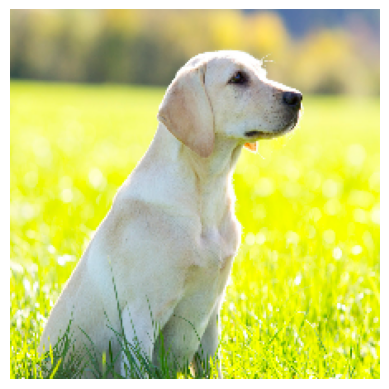

------result------
Labrador_retriever = 95.51%
golden_retriever = 3.77%
kuvasz = 0.17%
Great_Pyrenees = 0.14%
Great_Dane = 0.12%
English_foxhound = 0.10%
Walker_hound = 0.03%
beagle = 0.03%
Weimaraner = 0.02%
Greater_Swiss_Mountain_dog = 0.02%


In [13]:
# show result
plt.imshow(img)
plt.axis('off')
plt.show()

print("------result------")
for _, class_name , prob in decoded:
  print(f"{class_name} = {prob*100:.2f}%")